# 🤖 03 — Model Building
### World Development Clustering Pipeline

---

**Purpose:** Feature engineering + selection + training all 5 clustering models with full hyperparameter tuning.  
**Pipeline stages:** Stage 3a (Feature Engineering) + 3b (Feature Selection) + Stages 5–7 (GMM tuning, K selection, Model training)  
**Input:**  `data/processed/scaled_data.csv`  
**Output:** `data/processed/feature_reduced.csv`, `final_features.csv`, `pca_data.csv`, `models/*.pkl`

---

### 📐 Architecture
| Stage | Name | Key Logic |
|-------|------|-----------|
| 3a | Feature Engineering | Drop multicollinear (r=0.99), dynamic |r|>0.90 drop, PCA for viz ONLY |
| 3b | Feature Selection | Variance filter (threshold=0.01) |
| 5 | GMM Covariance Comparison | full / tied / diag → select by BIC |
| 6 | Optimal K Selection | Elbow + Silhouette sweep, BIC consensus |
| 7 | Train 5 Models | KMeans, GMM, Agglomerative, Spectral, BIRCH |

**PCA RULE:** PCA is **NEVER** applied before clustering. 2D coordinates for visualization only.

---
## 1. Environment Setup

In [1]:
import os
import sys
import pickle
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage as scipy_linkage, dendrogram
from IPython.display import display

from config.config import (
    SCALED_DATA, PROCESSED_DIR, MODELS_DIR,
    MULTICOLLINEAR_DROP, CORRELATION_DROP_THRESHOLD,
    PCA_VARIANCE_THRESHOLD, VARIANCE_FILTER_THRESHOLD,
    KMEANS_K_RANGE, KMEANS_PARAMS, GMM_PARAMS,
    HIERARCHICAL_PARAMS, SPECTRAL_PARAMS, BIRCH_PARAMS,
    PCA_MODEL_PATH, RANDOM_STATE, ID_COL,
)
from src.utils.helpers import get_numeric_feature_cols

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120})
PALETTE = sns.color_palette('tab10')
os.makedirs(MODELS_DIR, exist_ok=True)

print('✅ Environment ready')

✅ Environment ready


---
## Stage 3a — Feature Engineering
### Step 1: Drop Pre-Identified Multicollinear Columns

In [2]:
df = pd.read_csv(SCALED_DATA)
print(f'Loaded scaled_data | shape: {df.shape}')

# ── Pre-identified multicollinear drops ───────────────────────────────────────
# CO2 Emissions × Energy Usage: r = 0.993
# Life Expectancy Female × Male: r = 0.978
# Population 15-64 is derived from other population bands
cols_to_drop = [c for c in MULTICOLLINEAR_DROP if c in df.columns]
print(f'\nMulticollinear drops (domain knowledge):')
for c in cols_to_drop:
    feat_cols = get_numeric_feature_cols(df)
    if c in feat_cols:
        # Find its highest correlated partner
        corr_row = df[feat_cols].corr()[c].abs().drop(c).nlargest(1)
        print(f'  DROP  {c:<35}  (|r|={corr_row.values[0]:.3f} with {corr_row.index[0]})')

df = df.drop(columns=cols_to_drop)
print(f'\nShape after pre-identified drops: {df.shape}')

Loaded scaled_data | shape: (198, 28)

Multicollinear drops (domain knowledge):
  DROP  Energy Usage                         (|r|=0.973 with CO2 Emissions)
  DROP  Life Expectancy Male                 (|r|=0.978 with Life Expectancy Female)
  DROP  Population 15-64                     (|r|=0.926 with Population 0-14)

Shape after pre-identified drops: (198, 25)


### Step 2: Dynamic High-Correlation Drop (|r| > 0.90)

In [3]:
feat_cols   = get_numeric_feature_cols(df)
corr_matrix = df[feat_cols].corr().abs()
upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

dynamic_drops = [col for col in upper.columns if any(upper[col] > CORRELATION_DROP_THRESHOLD)]

print(f'Dynamic correlation drops (|r| > {CORRELATION_DROP_THRESHOLD}):')
for c in dynamic_drops:
    max_r_partner = upper[c][upper[c] > CORRELATION_DROP_THRESHOLD].idxmax()
    max_r         = upper[c].max()
    print(f'  DROP  {c:<35}  (|r|={max_r:.3f} with {max_r_partner})')

if dynamic_drops:
    df = df.drop(columns=dynamic_drops)

print(f'\nShape after dynamic drops: {df.shape}')

# ── Save feature_reduced.csv ──────────────────────────────────────────────────
FEATURE_REDUCED_PATH = os.path.join(PROCESSED_DIR, 'feature_reduced.csv')
df.to_csv(FEATURE_REDUCED_PATH, index=False)
print(f'✅ feature_reduced.csv saved')

Dynamic correlation drops (|r| > 0.9):
  DROP  Life Expectancy Female               (|r|=0.931 with Infant Mortality Rate)
  DROP  Population 0-14                      (|r|=0.951 with Birth Rate)
  DROP  Tourism Outbound                     (|r|=0.923 with GDP)
  DROP  GDP_trend                            (|r|=0.920 with CO2 Emissions)

Shape after dynamic drops: (198, 21)
✅ feature_reduced.csv saved


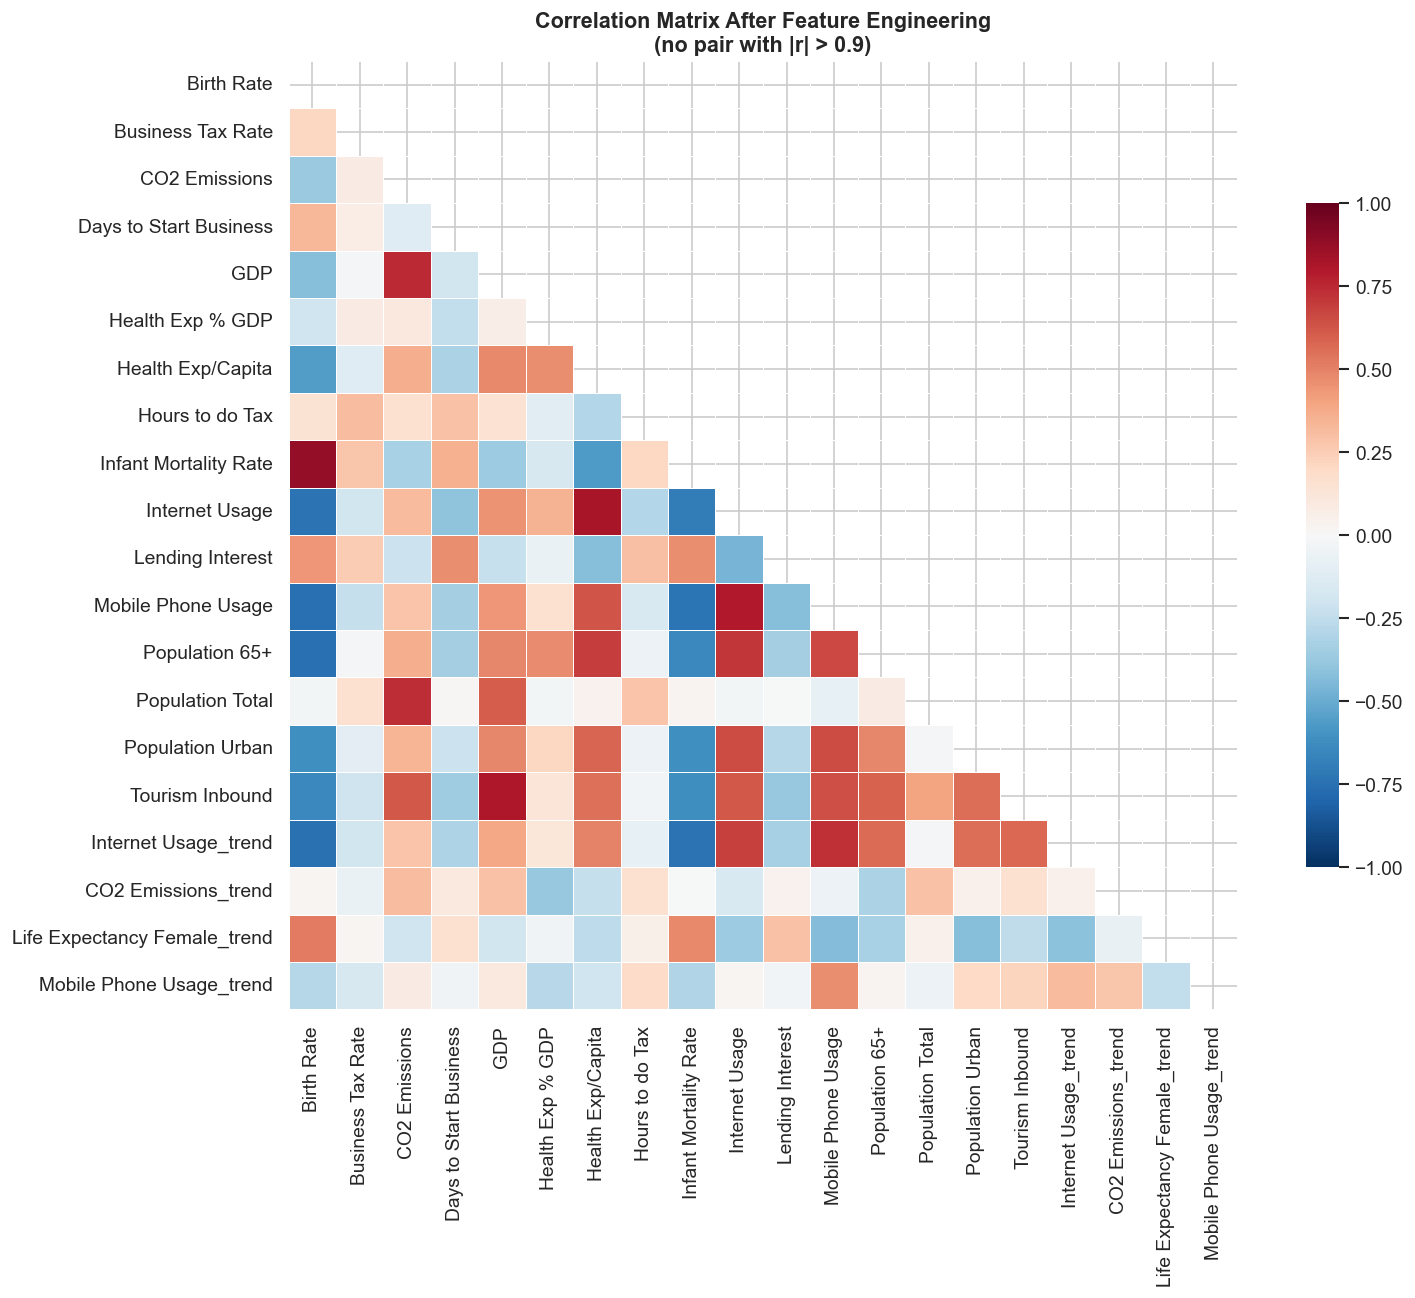

In [4]:
# ── Correlation heatmap post-engineering ─────────────────────────────────────
feat_cols_now = get_numeric_feature_cols(df)
corr_now      = df[feat_cols_now].corr()
mask          = np.triu(np.ones_like(corr_now, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_now, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, annot=False, ax=ax,
            cbar_kws={'shrink': 0.7})
ax.set_title(f'Correlation Matrix After Feature Engineering\n(no pair with |r| > {CORRELATION_DROP_THRESHOLD})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 3: PCA for Visualization (NOT for clustering)

> **Critical rule:** PCA output is **never** fed into any clustering model.  
> It is used exclusively for 2D/3D scatter plot coordinates.

PCA (visualization only):
  Threshold    : 90% variance
  n_components : 11
  Variance retained: 92.0%


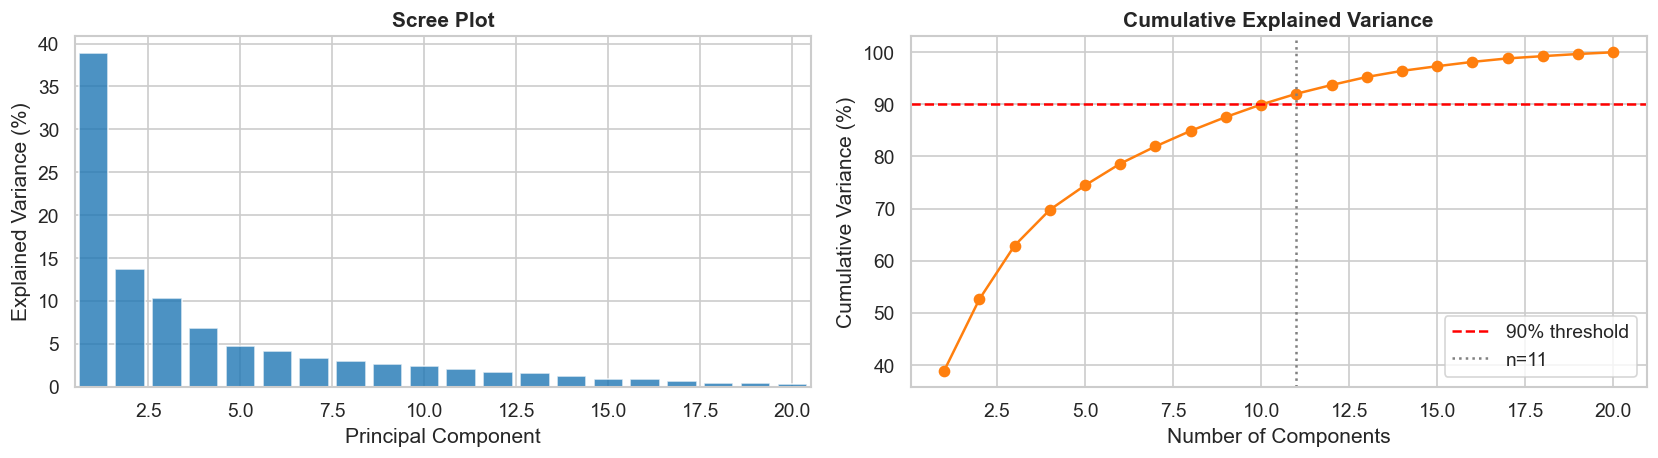


✅ PCA model saved | pca_data.csv saved | shape: (198, 12)


In [5]:
X_for_pca = df[feat_cols_now].values

# ── Determine n_components retaining PCA_VARIANCE_THRESHOLD variance ──────────
pca_full  = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_for_pca)
cumvar     = np.cumsum(pca_full.explained_variance_ratio_)
n_components = int(np.argmax(cumvar >= PCA_VARIANCE_THRESHOLD) + 1)

print(f'PCA (visualization only):')
print(f'  Threshold    : {PCA_VARIANCE_THRESHOLD*100:.0f}% variance')
print(f'  n_components : {n_components}')
print(f'  Variance retained: {cumvar[n_components-1]*100:.1f}%')

# ── Scree plot ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

evr = pca_full.explained_variance_ratio_
axes[0].bar(range(1, len(evr) + 1), evr * 100, color=PALETTE[0], alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].set_xlim(0.5, min(20.5, len(evr) + 0.5))

axes[1].plot(range(1, len(cumvar) + 1), cumvar * 100, 'o-', color=PALETTE[1])
axes[1].axhline(y=PCA_VARIANCE_THRESHOLD * 100, color='red', linestyle='--',
                label=f'{PCA_VARIANCE_THRESHOLD*100:.0f}% threshold')
axes[1].axvline(x=n_components, color='grey', linestyle=':', lw=1.5,
                label=f'n={n_components}')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Fit and save PCA model ────────────────────────────────────────────────────
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
components = pca.fit_transform(X_for_pca)
joblib.dump(pca, PCA_MODEL_PATH)

comp_cols = [f'PC{i+1}' for i in range(n_components)]
df_pca    = pd.DataFrame(components, columns=comp_cols)
if ID_COL in df.columns:
    df_pca.insert(0, ID_COL, df[ID_COL].values)

PCA_DATA_PATH = os.path.join(PROCESSED_DIR, 'pca_data.csv')
df_pca.to_csv(PCA_DATA_PATH, index=False)
print(f'\n✅ PCA model saved | pca_data.csv saved | shape: {df_pca.shape}')

---
## Stage 3b — Feature Selection
### Step 4: Variance Filter

Variance filter threshold: 0.01
Low-variance columns: []


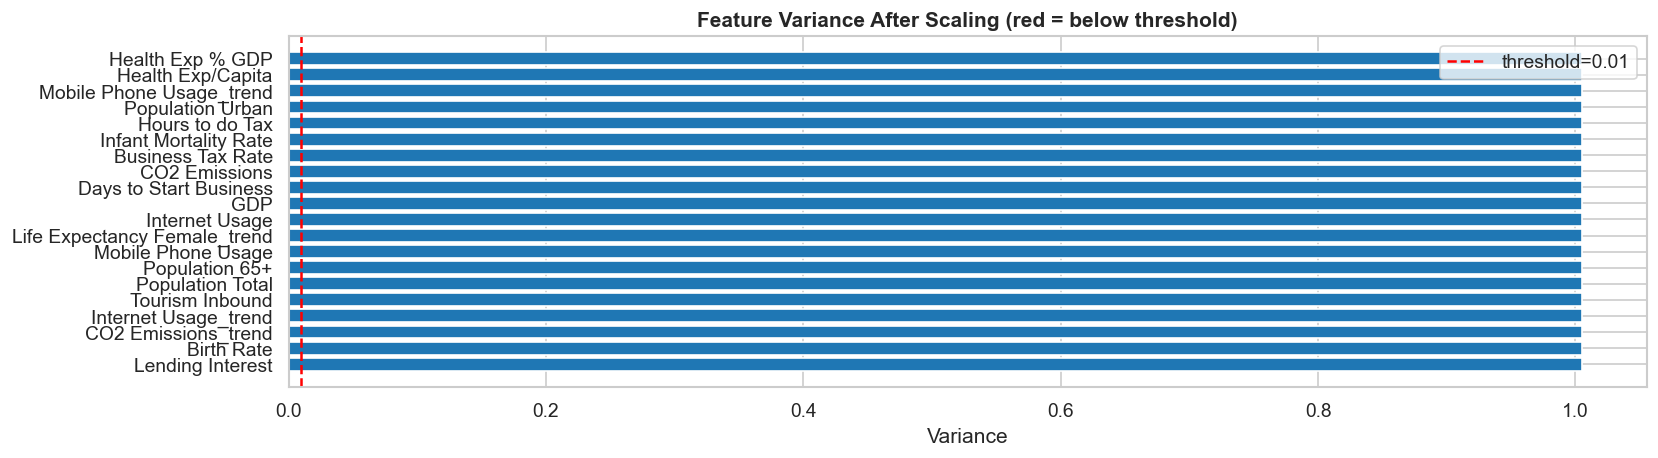


✅ final_features.csv saved | shape: (198, 21)
   Total features: 20 (4 trend features)
   Feature list: ['Birth Rate', 'Business Tax Rate', 'CO2 Emissions', 'Days to Start Business', 'GDP', 'Health Exp % GDP', 'Health Exp/Capita', 'Hours to do Tax', 'Infant Mortality Rate', 'Internet Usage', 'Lending Interest', 'Mobile Phone Usage', 'Population 65+', 'Population Total', 'Population Urban', 'Tourism Inbound', 'Internet Usage_trend', 'CO2 Emissions_trend', 'Life Expectancy Female_trend', 'Mobile Phone Usage_trend']

   Feature matrix shape: (198, 20)


In [6]:
feat_cols   = get_numeric_feature_cols(df)
variances   = df[feat_cols].var().sort_values()
low_var_cols = variances[variances < VARIANCE_FILTER_THRESHOLD].index.tolist()

print(f'Variance filter threshold: {VARIANCE_FILTER_THRESHOLD}')
print(f'Low-variance columns: {low_var_cols}')

# ── Variance distribution plot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
colors = ['#d62728' if v < VARIANCE_FILTER_THRESHOLD else '#1f77b4' for v in variances.values]
ax.barh(variances.index, variances.values, color=colors)
ax.axvline(VARIANCE_FILTER_THRESHOLD, color='red', linestyle='--', lw=1.5,
           label=f'threshold={VARIANCE_FILTER_THRESHOLD}')
ax.set_title('Feature Variance After Scaling (red = below threshold)', fontweight='bold')
ax.set_xlabel('Variance')
ax.legend()
plt.tight_layout()
plt.show()

if low_var_cols:
    df = df.drop(columns=low_var_cols)

FINAL_FEATURES_PATH = os.path.join(PROCESSED_DIR, 'final_features.csv')
df.to_csv(FINAL_FEATURES_PATH, index=False)

feat_cols_final = get_numeric_feature_cols(df)
trend_features  = [c for c in feat_cols_final if '_trend' in c]
print(f'\n✅ final_features.csv saved | shape: {df.shape}')
print(f'   Total features: {len(feat_cols_final)} ({len(trend_features)} trend features)')
print(f'   Feature list: {feat_cols_final}')

# ── Feature matrix ────────────────────────────────────────────────────────────
countries  = df[ID_COL].values if ID_COL in df.columns else None
X          = df[feat_cols_final].values
print(f'\n   Feature matrix shape: {X.shape}')

---
## Stage 5 — GMM Covariance Type Comparison

  covariance_type='full' | BIC=9315.27 | AIC=6280.20 | Silhouette=0.1892
  covariance_type='tied' | BIC=8921.90 | AIC=7958.44 | Silhouette=0.1862
  covariance_type='diag' | BIC=8040.94 | AIC=7504.95 | Silhouette=0.1749

✅ Selected covariance_type='diag' (lowest BIC)


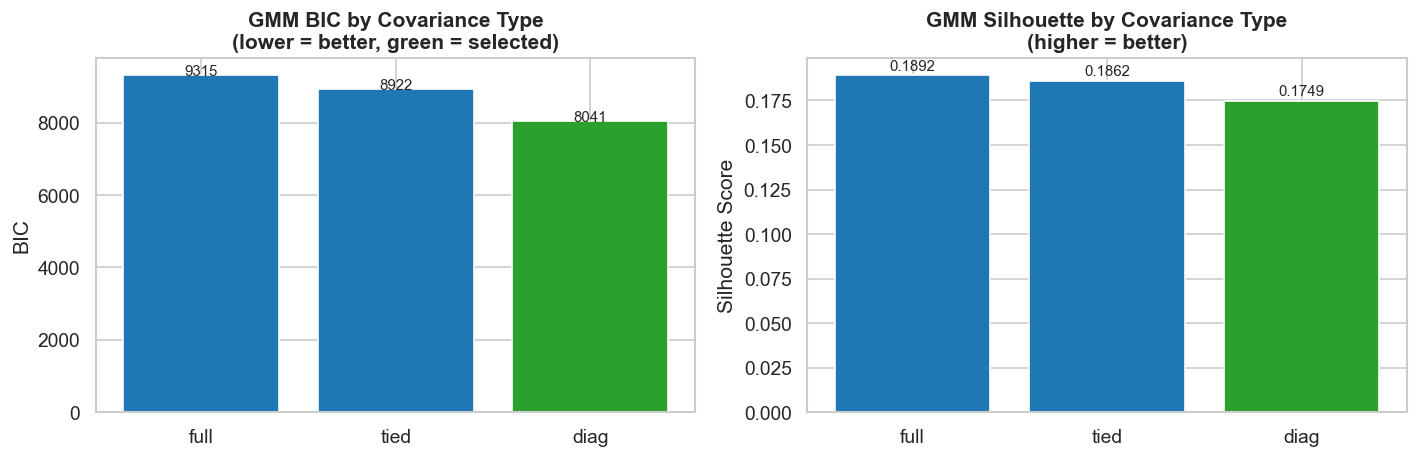

In [7]:
COV_TYPES = ('full', 'tied', 'diag')
K_PROBE   = 4  # use k=4 for covariance type comparison

cov_results = {}
for cov_type in COV_TYPES:
    gmm = GaussianMixture(n_components=K_PROBE, covariance_type=cov_type,
                          n_init=10, max_iter=200, random_state=RANDOM_STATE)
    gmm.fit(X)
    labels = gmm.predict(X)
    bic = gmm.bic(X)
    aic = gmm.aic(X)
    sil = silhouette_score(X, labels)
    cov_results[cov_type] = {'bic': round(bic, 2), 'aic': round(aic, 2), 'silhouette': round(sil, 4)}
    print(f"  covariance_type='{cov_type}' | BIC={bic:.2f} | AIC={aic:.2f} | Silhouette={sil:.4f}")

best_cov_type = min(COV_TYPES, key=lambda t: cov_results[t]['bic'])
print(f"\n✅ Selected covariance_type='{best_cov_type}' (lowest BIC)")

# ── BIC/Silhouette comparison bar chart ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bics = [cov_results[t]['bic'] for t in COV_TYPES]
sils = [cov_results[t]['silhouette'] for t in COV_TYPES]
bar_colors = ['#2ca02c' if t == best_cov_type else '#1f77b4' for t in COV_TYPES]

axes[0].bar(COV_TYPES, bics, color=bar_colors)
axes[0].set_title('GMM BIC by Covariance Type\n(lower = better, green = selected)', fontweight='bold')
axes[0].set_ylabel('BIC')
for i, v in enumerate(bics):
    axes[0].text(i, v + 5, f'{v:.0f}', ha='center', fontsize=9)

axes[1].bar(COV_TYPES, sils, color=bar_colors)
axes[1].set_title('GMM Silhouette by Covariance Type\n(higher = better)', fontweight='bold')
axes[1].set_ylabel('Silhouette Score')
for i, v in enumerate(sils):
    axes[1].text(i, v + 0.003, f'{v:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## Stage 6 — Optimal K Selection (Elbow + Silhouette + BIC)

In [8]:
# ── KMeans: Elbow + Silhouette sweep ─────────────────────────────────────────
K_RANGE    = list(KMEANS_K_RANGE)
km_inertia = []
km_sil     = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                random_state=RANDOM_STATE, max_iter=300)
    labels = km.fit_predict(X)
    sil    = silhouette_score(X, labels)
    km_inertia.append(km.inertia_)
    km_sil.append(sil)
    print(f'  KMeans k={k} | inertia={km.inertia_:.2f} | silhouette={sil:.4f}')

# ── GMM: BIC sweep ────────────────────────────────────────────────────────────
gmm_bic = []
gmm_sil = []

for k in K_RANGE:
    gmm = GaussianMixture(n_components=k, covariance_type=best_cov_type,
                          n_init=5, random_state=RANDOM_STATE)
    gmm.fit(X)
    labels = gmm.predict(X)
    bic    = gmm.bic(X)
    sil    = silhouette_score(X, labels)
    gmm_bic.append(bic)
    gmm_sil.append(sil)
    print(f'  GMM  k={k} | BIC={bic:.2f}  | silhouette={sil:.4f}')

# ── k=2 check (15% silhouette improvement rule) ───────────────────────────────
km2  = KMeans(n_clusters=2, init='k-means++', n_init=10, random_state=RANDOM_STATE)
sil2 = silhouette_score(X, km2.fit_predict(X))
best_in_range_sil = max(km_sil)
admit_k2 = sil2 > best_in_range_sil * 1.15
print(f'\n  k=2 silhouette={sil2:.4f} | {"ADMITTED" if admit_k2 else "REJECTED"} (threshold: +15% over best-in-range={best_in_range_sil:.4f})')

# ── Consensus: argmax silhouette (KMeans) vs argmin BIC (GMM) ─────────────────
best_sil_k = K_RANGE[np.argmax(km_sil)]
best_bic_k = K_RANGE[np.argmin(gmm_bic)]
votes      = Counter([best_sil_k, best_bic_k])
optimal_k  = votes.most_common(1)[0][0]

print(f'\n  Silhouette best k = {best_sil_k}  |  BIC best k = {best_bic_k}  |  Consensus = {optimal_k}')

  KMeans k=3 | inertia=2391.29 | silhouette=0.2086
  KMeans k=4 | inertia=2088.76 | silhouette=0.2237
  KMeans k=5 | inertia=1965.49 | silhouette=0.1545
  KMeans k=6 | inertia=1865.69 | silhouette=0.1450
  GMM  k=3 | BIC=8576.66  | silhouette=0.1941
  GMM  k=4 | BIC=8041.00  | silhouette=0.1749
  GMM  k=5 | BIC=7856.58  | silhouette=0.1345
  GMM  k=6 | BIC=7657.87  | silhouette=0.1083

  k=2 silhouette=0.2446 | REJECTED (threshold: +15% over best-in-range=0.2237)

  Silhouette best k = 4  |  BIC best k = 6  |  Consensus = 4


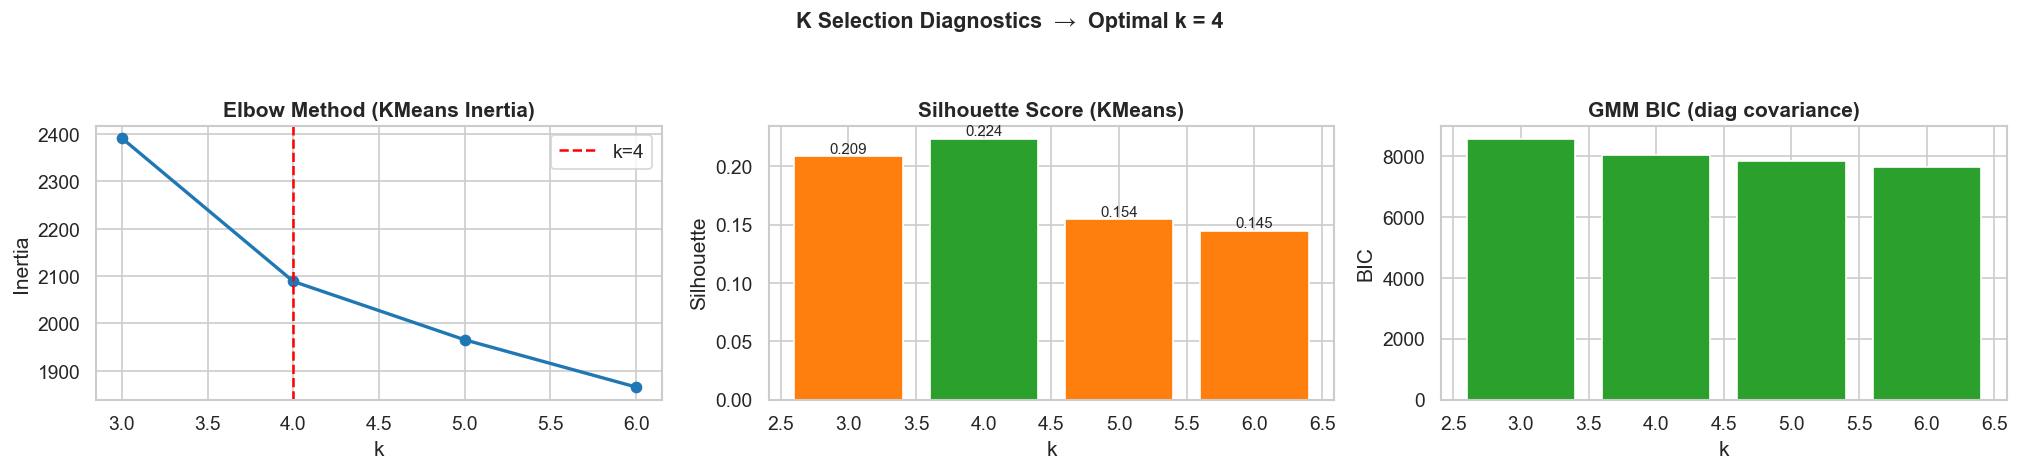

In [9]:
# ── K selection diagnostic plots ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Elbow
axes[0].plot(K_RANGE, km_inertia, 'o-', color=PALETTE[0], lw=2)
axes[0].axvline(x=optimal_k, color='red', linestyle='--', lw=1.5, label=f'k={optimal_k}')
axes[0].set_title('Elbow Method (KMeans Inertia)', fontweight='bold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].legend()

# Silhouette
bar_colors = ['#2ca02c' if k == optimal_k else PALETTE[1] for k in K_RANGE]
axes[1].bar(K_RANGE, km_sil, color=bar_colors)
axes[1].set_title('Silhouette Score (KMeans)', fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
for i, v in enumerate(km_sil):
    axes[1].text(K_RANGE[i], v + 0.003, f'{v:.3f}', ha='center', fontsize=9)

# BIC
bic_colors = ['#2ca02c' if k == optimal_k else PALETTE[2] for k in K_RANGE]
axes[2].bar(K_RANGE, gmm_bic, color=bic_colors)
axes[2].set_title(f'GMM BIC ({best_cov_type} covariance)', fontweight='bold')
axes[2].set_xlabel('k')
axes[2].set_ylabel('BIC')

plt.suptitle(f'K Selection Diagnostics  →  Optimal k = {optimal_k}', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

---
## Stage 7 — Train All 5 Models
### Model 1: KMeans (PRIMARY)

In [10]:
params_km  = {**KMEANS_PARAMS, 'n_clusters': optimal_k}
km_model   = KMeans(**params_km)
km_model.fit(X)
km_labels  = km_model.predict(X)
km_sil_final = silhouette_score(X, km_labels)
km_db        = davies_bouldin_score(X, km_labels)

print(f'KMeans (k={optimal_k}, n_init={params_km["n_init"]}):')
print(f'  Silhouette     : {km_sil_final:.4f}')
print(f'  Davies-Bouldin : {km_db:.4f}')
print(f'  Inertia        : {km_model.inertia_:.2f}')
print(f'  Cluster sizes  : {dict(zip(*np.unique(km_labels, return_counts=True)))}')

with open(os.path.join(MODELS_DIR, 'kmeans_model.pkl'), 'wb') as f:
    pickle.dump(km_model, f)
print('  ✅ kmeans_model.pkl saved')

KMeans (k=4, n_init=10):
  Silhouette     : 0.2237
  Davies-Bouldin : 1.4700
  Inertia        : 2088.76
  Cluster sizes  : {0: 72, 1: 67, 2: 31, 3: 28}
  ✅ kmeans_model.pkl saved


### Model 2: GMM (BIC-tuned covariance)

In [11]:
params_gmm  = {**GMM_PARAMS, 'n_components': optimal_k, 'covariance_type': best_cov_type}
gmm_model   = GaussianMixture(**params_gmm)
gmm_model.fit(X)
gmm_labels  = gmm_model.predict(X)
gmm_sil     = silhouette_score(X, gmm_labels)
gmm_db      = davies_bouldin_score(X, gmm_labels)
gmm_bic_val = gmm_model.bic(X)
gmm_aic_val = gmm_model.aic(X)

print(f"GMM (k={optimal_k}, covariance_type='{best_cov_type}', n_init={params_gmm['n_init']}):'")
print(f'  Silhouette     : {gmm_sil:.4f}')
print(f'  Davies-Bouldin : {gmm_db:.4f}')
print(f'  BIC            : {gmm_bic_val:.2f}')
print(f'  AIC            : {gmm_aic_val:.2f}')
print(f'  Converged      : {gmm_model.converged_}')
print(f'  Cluster sizes  : {dict(zip(*np.unique(gmm_labels, return_counts=True)))}')

# ── GMM probability distribution ─────────────────────────────────────────────
probs = gmm_model.predict_proba(X)
max_probs = probs.max(axis=1)
print(f'  Avg max-cluster probability: {max_probs.mean():.3f}')

joblib.dump(gmm_model, os.path.join(MODELS_DIR, 'gmm_model.pkl'))
print('  ✅ gmm_model.pkl saved')

GMM (k=4, covariance_type='diag', n_init=10):'
  Silhouette     : 0.1749
  Davies-Bouldin : 1.6825
  BIC            : 8040.94
  AIC            : 7504.95
  Converged      : True
  Cluster sizes  : {0: 49, 1: 47, 2: 62, 3: 40}
  Avg max-cluster probability: 0.994
  ✅ gmm_model.pkl saved


### Model 3: Agglomerative Hierarchical (linkage tuning)

In [12]:
# ── Tune linkage: ward / complete / average ───────────────────────────────────
LINKAGE_METHODS = ('ward', 'complete', 'average')
linkage_sils = {}

for method in LINKAGE_METHODS:
    params_link = {'n_clusters': optimal_k, 'linkage': method}
    if method != 'ward':
        params_link['metric'] = 'euclidean'
    model  = AgglomerativeClustering(**params_link)
    labels = model.fit_predict(X)
    sil    = silhouette_score(X, labels)
    linkage_sils[method] = sil
    print(f"  linkage='{method}' | silhouette={sil:.4f}")

best_linkage = max(linkage_sils, key=linkage_sils.get)
print(f"\n  Best linkage: '{best_linkage}' (silhouette={linkage_sils[best_linkage]:.4f})")

# ── Compute scipy linkage matrix for dendrogram ───────────────────────────────
Z = scipy_linkage(X, method=best_linkage)
LINKAGE_MATRIX_PATH = os.path.join(MODELS_DIR, 'linkage_matrix.pkl')
with open(LINKAGE_MATRIX_PATH, 'wb') as f:
    pickle.dump(Z, f)

# ── Train final hierarchical model ───────────────────────────────────────────
params_hc = {'n_clusters': optimal_k, 'linkage': best_linkage}
if best_linkage != 'ward':
    params_hc['metric'] = 'euclidean'
hc_model = AgglomerativeClustering(**params_hc)
hc_model.fit(X)
hc_labels = hc_model.labels_
hc_sil    = silhouette_score(X, hc_labels)
hc_db     = davies_bouldin_score(X, hc_labels)

print(f'\nAgglomerative (k={optimal_k}, linkage={best_linkage}):')
print(f'  Silhouette     : {hc_sil:.4f}')
print(f'  Davies-Bouldin : {hc_db:.4f}')
print(f'  Cluster sizes  : {dict(zip(*np.unique(hc_labels, return_counts=True)))}')

with open(os.path.join(MODELS_DIR, 'hierarchical_model.pkl'), 'wb') as f:
    pickle.dump(hc_model, f)
print('  ✅ hierarchical_model.pkl + linkage_matrix.pkl saved')

  linkage='ward' | silhouette=0.1890
  linkage='complete' | silhouette=0.1916
  linkage='average' | silhouette=0.2108

  Best linkage: 'average' (silhouette=0.2108)

Agglomerative (k=4, linkage=average):
  Silhouette     : 0.2108
  Davies-Bouldin : 1.2199
  Cluster sizes  : {0: 61, 1: 2, 2: 133, 3: 2}
  ✅ hierarchical_model.pkl + linkage_matrix.pkl saved


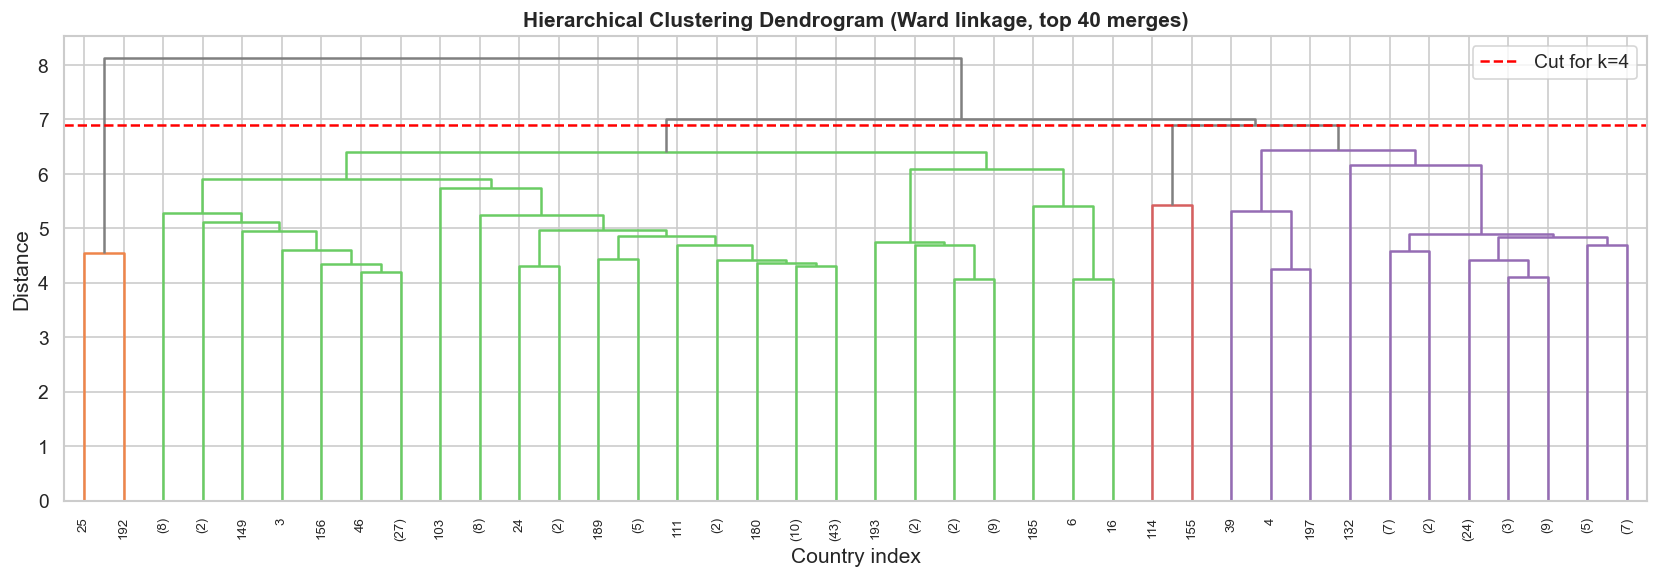

In [13]:
# ── Dendrogram (truncated) ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=40, leaf_rotation=90,
           color_threshold=Z[-(optimal_k - 1), 2],
           above_threshold_color='grey')
ax.set_title(f'Hierarchical Clustering Dendrogram (Ward linkage, top 40 merges)', fontweight='bold')
ax.set_xlabel('Country index')
ax.set_ylabel('Distance')
ax.axhline(y=Z[-(optimal_k - 1), 2], color='red', linestyle='--', lw=1.5,
           label=f'Cut for k={optimal_k}')
ax.legend()
plt.tight_layout()
plt.show()

### Model 4: Spectral (affinity tuning)

In [14]:
AFFINITIES   = ('rbf', 'nearest_neighbors')
affinity_sils = {}

for affinity in AFFINITIES:
    try:
        model  = SpectralClustering(n_clusters=optimal_k, affinity=affinity,
                                    n_init=10, random_state=RANDOM_STATE, assign_labels='kmeans')
        labels = model.fit_predict(X)
        sil    = silhouette_score(X, labels)
        affinity_sils[affinity] = sil
        print(f"  affinity='{affinity}' | silhouette={sil:.4f}")
    except Exception as e:
        print(f"  affinity='{affinity}' failed: {e}")
        affinity_sils[affinity] = -1.0

best_affinity = max(affinity_sils, key=affinity_sils.get)
print(f"\n  Best affinity: '{best_affinity}'")

spectral_model = SpectralClustering(
    n_clusters=optimal_k, affinity=best_affinity,
    n_init=SPECTRAL_PARAMS['n_init'], random_state=RANDOM_STATE,
    assign_labels=SPECTRAL_PARAMS['assign_labels'],
)
spectral_model.fit(X)
spectral_labels = spectral_model.labels_
spec_sil = silhouette_score(X, spectral_labels)
spec_db  = davies_bouldin_score(X, spectral_labels)

print(f'\nSpectral (k={optimal_k}, affinity={best_affinity}):')
print(f'  Silhouette     : {spec_sil:.4f}')
print(f'  Davies-Bouldin : {spec_db:.4f}')
print(f'  Cluster sizes  : {dict(zip(*np.unique(spectral_labels, return_counts=True)))}')

with open(os.path.join(MODELS_DIR, 'spectral_model.pkl'), 'wb') as f:
    pickle.dump(spectral_model, f)
print('  ✅ spectral_model.pkl saved')

  affinity='rbf' | silhouette=0.0830
  affinity='nearest_neighbors' | silhouette=0.2164

  Best affinity: 'nearest_neighbors'

Spectral (k=4, affinity=nearest_neighbors):
  Silhouette     : 0.2164
  Davies-Bouldin : 1.4965
  Cluster sizes  : {0: 79, 1: 64, 2: 32, 3: 23}
  ✅ spectral_model.pkl saved


### Model 5: BIRCH (threshold tuning)

In [15]:
THRESHOLDS   = [0.3, 0.5, 0.7, 1.0, 1.5]
threshold_sils = {}

for t in THRESHOLDS:
    try:
        model  = Birch(n_clusters=optimal_k, threshold=t,
                       branching_factor=BIRCH_PARAMS['branching_factor'])
        labels = model.fit_predict(X)
        if len(set(labels)) < 2:
            print(f'  threshold={t} → {len(set(labels))} cluster — skip')
            threshold_sils[t] = -1.0
            continue
        sil = silhouette_score(X, labels)
        threshold_sils[t] = sil
        print(f'  threshold={t} | silhouette={sil:.4f}')
    except Exception as e:
        print(f'  threshold={t} failed: {e}')
        threshold_sils[t] = -1.0

best_threshold = max(threshold_sils, key=threshold_sils.get)
print(f'\n  Best threshold: {best_threshold}')

birch_model = Birch(n_clusters=optimal_k, threshold=best_threshold,
                    branching_factor=BIRCH_PARAMS['branching_factor'])
birch_model.fit(X)
birch_labels = birch_model.labels_
birch_sil    = silhouette_score(X, birch_labels)
birch_db     = davies_bouldin_score(X, birch_labels)

print(f'\nBIRCH (k={optimal_k}, threshold={best_threshold}):')
print(f'  Silhouette     : {birch_sil:.4f}')
print(f'  Davies-Bouldin : {birch_db:.4f}')
print(f'  Cluster sizes  : {dict(zip(*np.unique(birch_labels, return_counts=True)))}')

with open(os.path.join(MODELS_DIR, 'birch_model.pkl'), 'wb') as f:
    pickle.dump(birch_model, f)
print('  ✅ birch_model.pkl saved')

  threshold=0.3 | silhouette=0.1890
  threshold=0.5 | silhouette=0.1890
  threshold=0.7 | silhouette=0.1857
  threshold=1.0 | silhouette=0.1983
  threshold=1.5 | silhouette=0.1902

  Best threshold: 1.0

BIRCH (k=4, threshold=1.0):
  Silhouette     : 0.1983
  Davies-Bouldin : 1.4429
  Cluster sizes  : {0: 102, 1: 55, 2: 22, 3: 19}
  ✅ birch_model.pkl saved


2026-05-03 20:15:15 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-03 20:15:15 | INFO     | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


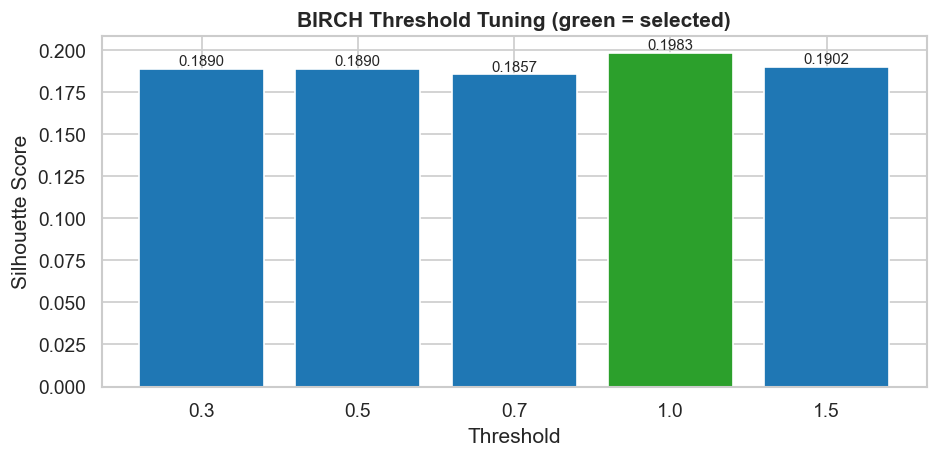

In [16]:
# ── BIRCH threshold sweep visualization ──────────────────────────────────────
valid_t   = [(t, s) for t, s in threshold_sils.items() if s > 0]
if valid_t:
    ts, ss = zip(*valid_t)
    bar_c  = ['#2ca02c' if t == best_threshold else '#1f77b4' for t in ts]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar([str(t) for t in ts], ss, color=bar_c)
    ax.set_title('BIRCH Threshold Tuning (green = selected)', fontweight='bold')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Silhouette Score')
    for i, v in enumerate(ss):
        ax.text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()

---
## Model Summary & PCA-2D Cluster Scatter

All 5 Models Trained — Metrics Summary:


,Model,k,Silhouette,Davies-Bouldin
0,KMeans,4,0.2237,1.4700
3,Spectral (nearest_neighbors),4,0.2164,1.4965
2,Agglomerative (average),4,0.2108,1.2199
4,BIRCH (t=1.0),4,0.1983,1.4429
1,GMM (diag),4,0.1749,1.6825


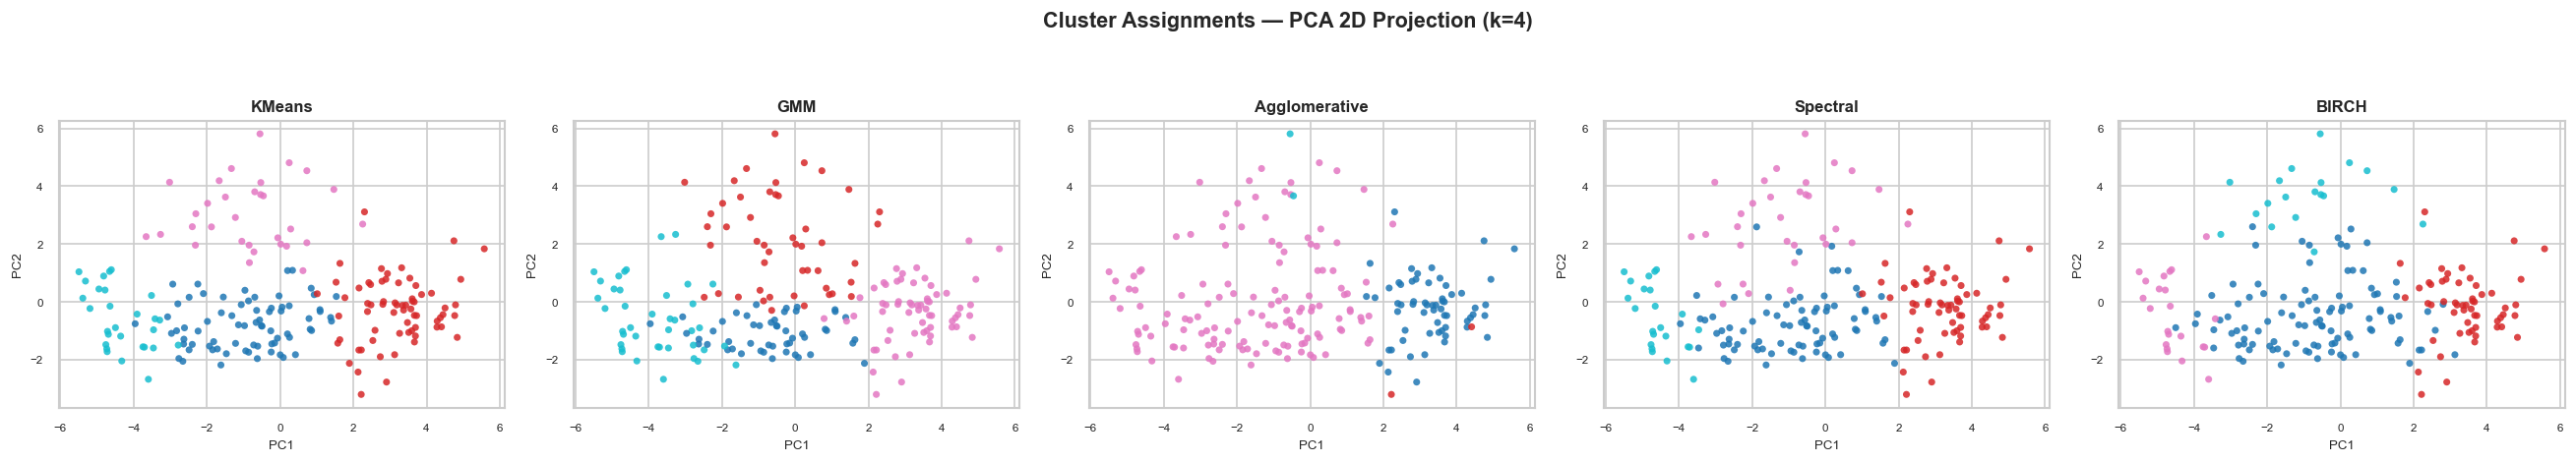


✅ All 5 models built — proceed to Notebook 04: Model Evaluation


In [17]:
# ── Metrics comparison table ──────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model'          : ['KMeans', f'GMM ({best_cov_type})', f'Agglomerative ({best_linkage})',
                        f'Spectral ({best_affinity})', f'BIRCH (t={best_threshold})'],
    'k'              : [optimal_k] * 5,
    'Silhouette'     : [km_sil_final, gmm_sil, hc_sil, spec_sil, birch_sil],
    'Davies-Bouldin' : [km_db, gmm_db, hc_db, spec_db, birch_db],
})
summary['Silhouette']     = summary['Silhouette'].round(4)
summary['Davies-Bouldin'] = summary['Davies-Bouldin'].round(4)
summary = summary.sort_values('Silhouette', ascending=False)

print('All 5 Models Trained — Metrics Summary:')
display(summary)

# ── PCA 2D scatter (5 panels) ─────────────────────────────────────────────────
df_pca_loaded = pd.read_csv(PCA_DATA_PATH)
pc1 = df_pca_loaded['PC1'].values
pc2 = df_pca_loaded['PC2'].values

all_labels = {
    'KMeans'           : km_labels,
    f'GMM'             : gmm_labels,
    'Agglomerative'    : hc_labels,
    'Spectral'         : spectral_labels,
    'BIRCH'            : birch_labels,
}

fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for ax, (name, lbl) in zip(axes, all_labels.items()):
    scatter = ax.scatter(pc1, pc2, c=lbl, cmap='tab10', s=18, alpha=0.85, edgecolors='none')
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel('PC1', fontsize=8)
    ax.set_ylabel('PC2', fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle(f'Cluster Assignments — PCA 2D Projection (k={optimal_k})', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

print('\n✅ All 5 models built — proceed to Notebook 04: Model Evaluation')